<a href="https://colab.research.google.com/github/srimathichinnasamy/aiml_assignment/blob/main/aiml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
from google.colab import files
uploaded = files.upload()
df = pd.read_excel("face_recognition_papers.xlsx")

# Drop unnecessary text columns
df = df.drop(columns=["Author", "Paper Title", "Result"])

# Encode categorical columns
le = LabelEncoder()

for col in df.columns:
    df[col] = le.fit_transform(df[col].astype(str))

# Split features and target
X = df.drop(columns=["Correctness"])
y = df["Correctness"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Results
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Saving face_recognition_papers.xlsx to face_recognition_papers.xlsx
Accuracy: 0.6666666666666666
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       0.00      0.00      0.00         1

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.6666666666666666


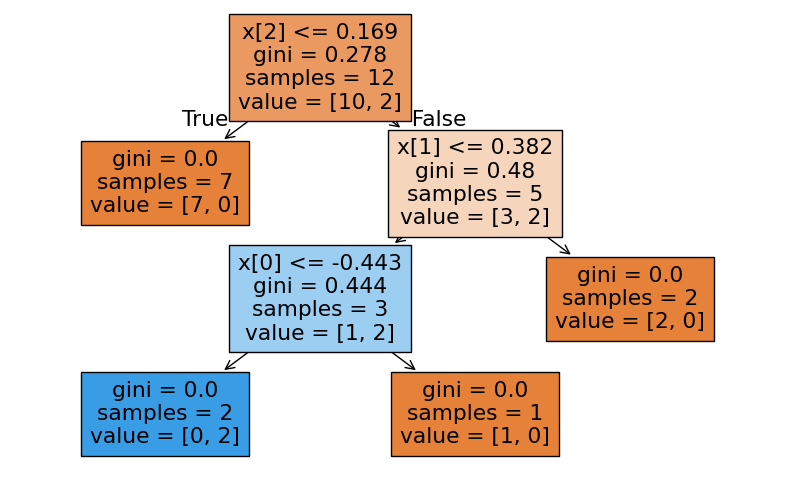

In [4]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Model
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

# Plot
plt.figure(figsize=(10,6))
plot_tree(model, filled=True)
plt.show()

Accuracy: 0.6666666666666666


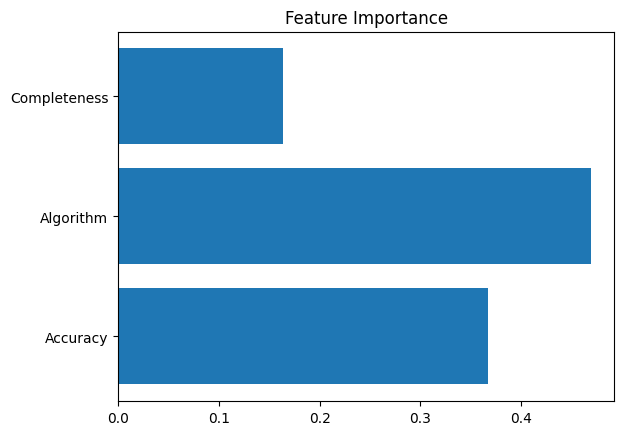

In [5]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

# Feature Importance
importances = model.feature_importances_

plt.figure()
plt.barh(X.columns, importances)
plt.title("Feature Importance")
plt.show()

Mean Squared Error: 5.642537916836834
R2 Score: 0.3489379326726729


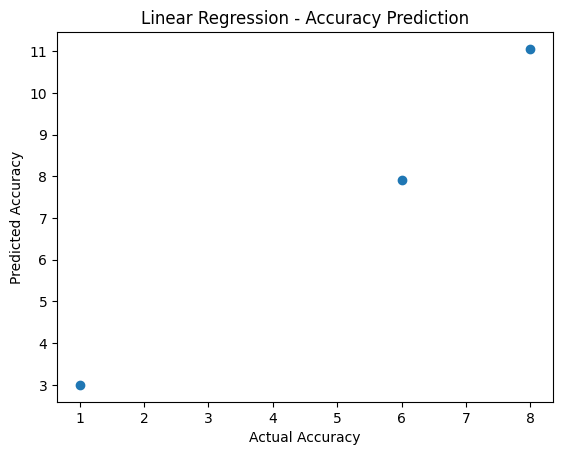

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_excel("face_recognition_papers.xlsx")

# Drop unnecessary text columns
df = df.drop(columns=["Author", "Paper Title", "Result"])

# Convert categorical → numeric using Label Encoding
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col].astype(str))

# Features and Target
X = df.drop(columns=["Accuracy"])   # Predicting Accuracy
y = df["Accuracy"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# Plot
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Accuracy")
plt.ylabel("Predicted Accuracy")
plt.title("Linear Regression - Accuracy Prediction")
plt.show()